# Redes Neuronales

In [35]:
#!pip install tensorflow

In [36]:
from dotenv import load_dotenv
import os

load_dotenv()  # carga automáticamente el .env de la raíz

DATA_DIR           = os.getenv("DATA_DIR", "./data")
RAW_DATA_PATH      = os.getenv("RAW_DATA_PATH", "./data/raw/dataset.xlsx")
PROCESSED_DATA_PATH= os.getenv("PROCESSED_DATA_PATH", "./data/processed/dataset_procesado.pkl")
MODELS_DIR         = os.getenv("MODELS_DIR", "./models")
RANDOM_SEED        = int(os.getenv("RANDOM_SEED", 42))

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
import re
warnings.filterwarnings('ignore')

from keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from tf_keras.preprocessing.text import Tokenizer
from tf_keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, precision_recall_curve, 
                             roc_auc_score, roc_curve, cohen_kappa_score)

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.21.0


In [38]:
# Datos
df = pd.read_excel('../data/rad_criticos.xlsx')

patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']


In [39]:
# =============================================================================
# ETIQUETADO DE PATOLOGÍAS (generado automáticamente desde Hallazgos + Opinión)
# =============================================================================

def detectar_patologia_robusta(texto, keywords_positivos, keywords_negativos=None):
    """Detecta patologías con análisis de contexto robusto (ventana de negación)."""
    if not isinstance(texto, str):
        return 0
    texto = texto.lower()
    keywords_negativos = keywords_negativos or [
        'antiguo','antigua','cronico','cronica','crónico','crónica',
        'viejo','vieja','residual','residuales','secuela','secuelar','secuelas',
        'previo','previa','previos','previas','conocido','conocida',
        'sin cambios','estable','estables','resolucion','resolución'
    ]
    negaciones_contextuales = [
        'sin','descarta','descartado','descartada','negativo','negativa',
        'ausencia','ausente','ausentes','sin evidencia','sin signos',
        'no se observa','no se observan','no se evidencia','no se evidencian',
        'no se identifica','no se identifican','libre de',
        'negativo para','negativa para'
    ]
    keywords_ordenadas = sorted(keywords_positivos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    for oracion in oraciones:
        oracion = oracion.strip()
        keyword_encontrada = next((kw for kw in keywords_ordenadas if kw in oracion), None)
        if not keyword_encontrada:
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:\s*no\b', oracion):
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b', oracion):
            continue
        idx_kw = oracion.find(keyword_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        if any(neg in segmento_previo for neg in negaciones_contextuales):
            continue
        if re.search(r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(keyword_encontrada), oracion):
            continue
        if any(ant in oracion for ant in keywords_negativos):
            continue
        if 'ya conocido' in oracion or 'ya conocida' in oracion:
            continue
        if 'sin cambios' in oracion:
            continue
        if 'resolucion' in oracion or 'resolución' in oracion:
            continue
        return 1
    return 0

texto_etiquetado = df['Hallazgos'] + ' ' + df['Opinión']

keywords = {
    'acv': [
        'infarto cerebral','infarto isquemico','accidente cerebrovascular',
        'hipodensidad sugestiva de isquemia','zona de isquemia',
        'area de isquemia','evento isquemico','ictus','acv','isquemia'
    ],
    'hemorragia': [
        'hemorragia subaracnoidea','hemorragia intraparenquimatosa',
        'hemorragia intraventricular','hematoma subdural','hematoma epidural',
        'hematoma intraparenquimatoso','sangrado intraparenquimatoso',
        'coleccion hematica','hemorragia','hematoma','sangrado'
    ],
    'desviacion_linea_media': [
        'desviacion de la linea media','desviacion linea media','linea media desplazada',
        'desplazamiento de la linea media','efecto de masa con desviacion',
        'shift de linea media','herniacion subfalcina','hernia subfalcina'
    ],
    'fractura_compleja_craneo': [
        'fractura con hundimiento','fractura hundimiento','fractura deprimida',
        'fractura conminuta','fractura compleja','fractura de base de craneo',
        'fractura craneofacial','fractura multiple de craneo'
    ]
}

for pat, kws in keywords.items():
    df[pat] = texto_etiquetado.apply(lambda t: detectar_patologia_robusta(t, kws))

print("Distribución de etiquetas generadas:")
for p in ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']:
    n = df[p].sum()
    print(f"  {p:12s}: {n:5d}  ({100*n/len(df):.1f}%)")

Distribución de etiquetas generadas:
  acv         :   323  (33.9%)
  hemorragia  :   813  (85.4%)
  desviacion_linea_media:   129  (13.6%)
  fractura_compleja_craneo:    30  (3.2%)


In [40]:
# Extraer X e y (después del etiquetado automático)
X_text = df['Hallazgos'].astype(str).values
y = df[patologias].values

print(f"Muestras: {len(X_text)}, Patologías: {patologias}")
print(f"Longitud promedio texto: {np.mean([len(t.split()) for t in X_text]):.0f} palabras")
print()
print("Distribución de etiquetas:")
for p in patologias:
    n = df[p].sum()
    print(f"  {p:12s}: {n:5d}  ({100*n/len(df):.1f}%)")


Muestras: 952, Patologías: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
Longitud promedio texto: 152 palabras

Distribución de etiquetas:
  acv         :   323  (33.9%)
  hemorragia  :   813  (85.4%)
  desviacion_linea_media:   129  (13.6%)
  fractura_compleja_craneo:    30  (3.2%)


In [41]:
# Hiperparámetros optimizados para Hallazgos
# ============================================================
TEXT    = "Hallazgos"
VOCAB   = 12000
MAXLEN  = 200
EMB_DIM = 100
BATCH   = 16
EPOCHS  = 20

# Etiquetas descriptivas por patología
ETIQUETAS = {
    'hemorragia': ['Sin hemorragia', 'Hemorragia'],
    'acv':        ['Sin ACV', 'ACV'],
    'fractura_compleja_craneo':   ['Sin fractura compleja de craneo', 'Fractura compleja de craneo'],
    'desviacion_linea_media':       ['Sin desviacion de linea media', 'Desviacion de linea media']
}

In [42]:
from keras.layers import SpatialDropout1D

def build_lstm(vocab=VOCAB, maxlen=MAXLEN, emb_dim=EMB_DIM):
    """
    Arquitectura mejorada para texto combinado:
    - SpatialDropout1D después de Embedding (regulariza embeddings)
    - LSTM más amplio (64→32) para capturar patrones complejos
    - Dropout 0.3 (menos agresivo, texto más rico)
    """
    model = Sequential([
        Embedding(vocab, emb_dim, input_length=maxlen),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def prep_text(train_text, test_text, vocab=VOCAB, maxlen=MAXLEN):
    tok = Tokenizer(num_words=vocab, oov_token="<OOV>")
    tok.fit_on_texts(train_text)
    Xtr = pad_sequences(tok.texts_to_sequences(train_text), maxlen=maxlen, padding="post")
    Xte = pad_sequences(tok.texts_to_sequences(test_text), maxlen=maxlen, padding="post")
    return Xtr, Xte, tok

## Definición Modelo

In [43]:
def train_and_eval(name, X_train, X_test, y_train, y_test):
    """Entrena y evalúa modelo con etiquetas descriptivas por patología"""
    print(f"\n{'='*60}")
    print(f">>> {name.upper()} <<<")
    print(f"{'='*60}")
    
    # Mostrar distribución de clases
    pos_train = y_train.sum()
    neg_train = len(y_train) - pos_train
    print(f"Train: {neg_train} negativos, {pos_train} positivos ({pos_train/len(y_train)*100:.1f}%)")
    
    # Etiquetas específicas para esta patología
    etiquetas = ETIQUETAS.get(name, ['Negativo', 'Positivo'])
    
    model = build_lstm()
    es = EarlyStopping(patience=4, restore_best_weights=True, verbose=1)
    
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=2
    )
    
    y_prob = model.predict(X_test, batch_size=BATCH).ravel()
    prec, rec, thr = precision_recall_curve(y_test, y_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr[np.nanargmax(f1)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    print(f"\nUmbral óptimo F1: {best_thr:.3f}\n")
    print(classification_report(y_test, y_pred, target_names=etiquetas, digits=3))
    
    # Matriz de confusión con etiquetas descriptivas
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    ConfusionMatrixDisplay(cm, display_labels=etiquetas).plot(ax=axes[0], cmap="Blues")
    axes[0].set_title(f"Matriz de Confusión - {name.capitalize()}")
    
    # Curva ROC
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[1].set_xlabel("Tasa Falsos Positivos")
    axes[1].set_ylabel("Tasa Verdaderos Positivos")
    axes[1].set_title(f"Curva ROC - {name.capitalize()}")
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # F1 por clase
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    # Cohen's Kappa
    kappa = cohen_kappa_score(y_test, y_pred)
    print(f"\nCohen's Kappa: {kappa:.4f}")
    
    return model, best_thr, {
        'AUC': auc, 
        'F1_pos': f1_pos, 
        'F1_neg': f1_neg,
        'Kappa': kappa,
        'history': history
    }

In [44]:
# Split datos
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)
X_train, X_test, tokenizer = prep_text(X_train_text, X_test_text)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 761, Test: 191



>>> ACV <<<
Train: 503 negativos, 258 positivos (33.9%)
Epoch 1/20
41/41 - 23s - 569ms/step - accuracy: 0.7353 - loss: 0.5053 - val_accuracy: 0.9043 - val_loss: 0.2730
Epoch 2/20
41/41 - 8s - 189ms/step - accuracy: 0.9443 - loss: 0.1696 - val_accuracy: 0.9217 - val_loss: 0.2254
Epoch 3/20
41/41 - 7s - 176ms/step - accuracy: 0.9721 - loss: 0.1047 - val_accuracy: 0.8870 - val_loss: 0.3512
Epoch 4/20
41/41 - 7s - 175ms/step - accuracy: 0.9876 - loss: 0.0564 - val_accuracy: 0.8957 - val_loss: 0.3627
Epoch 5/20
41/41 - 7s - 174ms/step - accuracy: 0.9954 - loss: 0.0238 - val_accuracy: 0.9043 - val_loss: 0.3608
Epoch 6/20
41/41 - 8s - 193ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.9043 - val_loss: 0.4035
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step

Umbral óptimo F1: 0.286

              precision    recall  f1-score   support

     Sin ACV      0.961     0.968     0.964       126
         ACV     

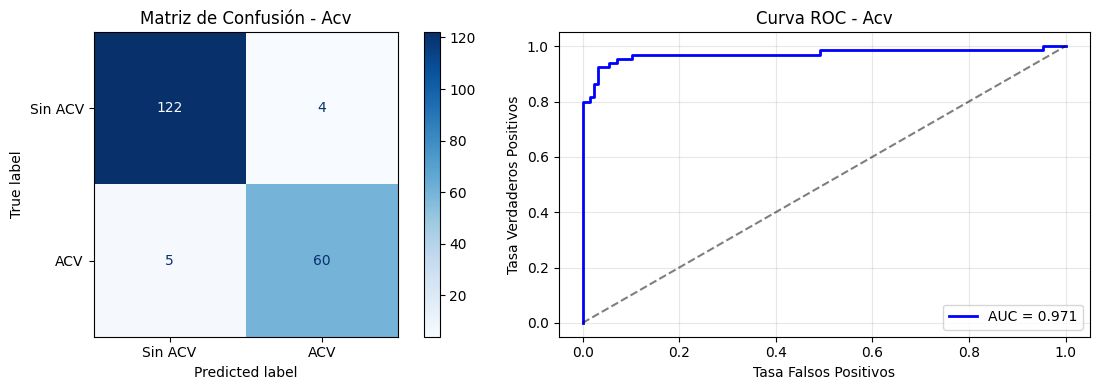


Cohen's Kappa: 0.8947

>>> HEMORRAGIA <<<
Train: 104 negativos, 657 positivos (86.3%)
Epoch 1/20
41/41 - 28s - 679ms/step - accuracy: 0.8622 - loss: 0.4327 - val_accuracy: 0.8522 - val_loss: 0.3974
Epoch 2/20
41/41 - 8s - 195ms/step - accuracy: 0.8793 - loss: 0.3144 - val_accuracy: 0.8696 - val_loss: 0.3104
Epoch 3/20
41/41 - 8s - 190ms/step - accuracy: 0.9180 - loss: 0.2023 - val_accuracy: 0.8348 - val_loss: 0.2647
Epoch 4/20
41/41 - 8s - 194ms/step - accuracy: 0.9598 - loss: 0.1345 - val_accuracy: 0.8348 - val_loss: 0.4516
Epoch 5/20
41/41 - 8s - 199ms/step - accuracy: 0.9675 - loss: 0.0959 - val_accuracy: 0.8435 - val_loss: 0.4224
Epoch 6/20
41/41 - 8s - 196ms/step - accuracy: 0.9907 - loss: 0.0413 - val_accuracy: 0.8609 - val_loss: 0.5428
Epoch 7/20
41/41 - 8s - 185ms/step - accuracy: 0.9923 - loss: 0.0325 - val_accuracy: 0.8522 - val_loss: 0.6169
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step

Umbral ópt

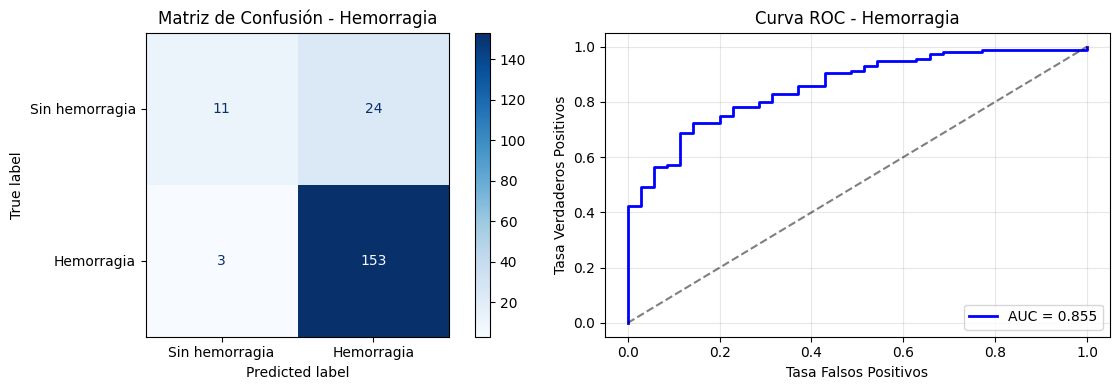


Cohen's Kappa: 0.3845

>>> DESVIACION_LINEA_MEDIA <<<
Train: 653 negativos, 108 positivos (14.2%)
Epoch 1/20
41/41 - 37s - 893ms/step - accuracy: 0.8591 - loss: 0.4312 - val_accuracy: 0.8348 - val_loss: 0.4354
Epoch 2/20
41/41 - 15s - 372ms/step - accuracy: 0.8607 - loss: 0.3994 - val_accuracy: 0.8348 - val_loss: 0.4456
Epoch 3/20
41/41 - 9s - 227ms/step - accuracy: 0.8715 - loss: 0.3432 - val_accuracy: 0.8348 - val_loss: 0.3893
Epoch 4/20
41/41 - 11s - 261ms/step - accuracy: 0.9164 - loss: 0.2018 - val_accuracy: 0.8261 - val_loss: 0.4675
Epoch 5/20
41/41 - 10s - 248ms/step - accuracy: 0.9505 - loss: 0.1396 - val_accuracy: 0.8348 - val_loss: 0.6053
Epoch 6/20
41/41 - 10s - 243ms/step - accuracy: 0.9598 - loss: 0.1247 - val_accuracy: 0.8000 - val_loss: 0.5147
Epoch 7/20
41/41 - 9s - 229ms/step - accuracy: 0.9752 - loss: 0.0755 - val_accuracy: 0.8435 - val_loss: 0.5135
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/

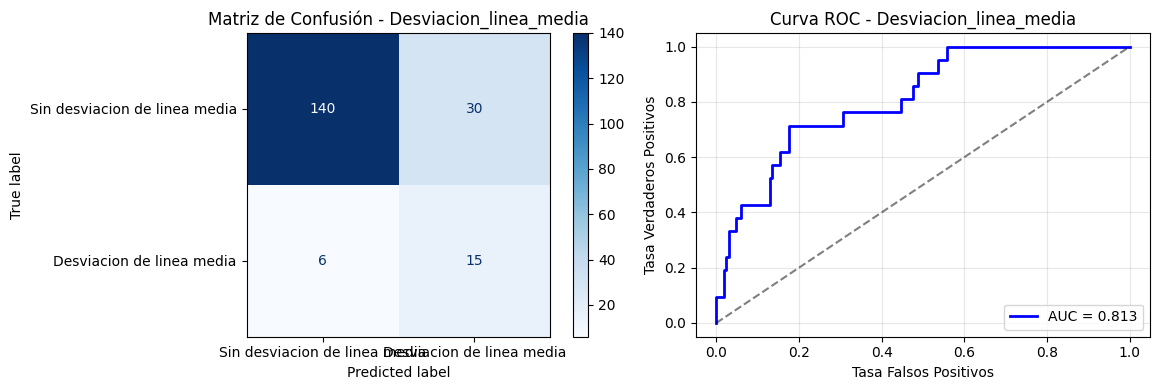


Cohen's Kappa: 0.3583

>>> FRACTURA_COMPLEJA_CRANEO <<<
Train: 737 negativos, 24 positivos (3.2%)
Epoch 1/20
41/41 - 24s - 580ms/step - accuracy: 0.9567 - loss: 0.2591 - val_accuracy: 1.0000 - val_loss: 0.0324
Epoch 2/20
41/41 - 9s - 222ms/step - accuracy: 0.9628 - loss: 0.1575 - val_accuracy: 1.0000 - val_loss: 0.0284
Epoch 3/20
41/41 - 8s - 197ms/step - accuracy: 0.9628 - loss: 0.1432 - val_accuracy: 1.0000 - val_loss: 0.0306
Epoch 4/20
41/41 - 8s - 204ms/step - accuracy: 0.9644 - loss: 0.1192 - val_accuracy: 1.0000 - val_loss: 0.0169
Epoch 5/20


In [ ]:
# Entrenar modelo por patología
modelos = {}
resultados = {}

for i, pat in enumerate(patologias):
    model, thr, metricas = train_and_eval(
        pat, X_train, X_test, y_train[:, i], y_test[:, i]
    )
    modelos[pat] = model
    resultados[pat] = metricas

In [28]:
# Resumen por patología
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10} {'Kappa':>10}")
print("-"*70)
for pat in patologias:
    r = resultados[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f} {r['Kappa']:>10.3f}")
print("="*70)

# Promedios
auc_promedio = np.mean([resultados[p]['AUC'] for p in patologias])
kappa_promedio = np.mean([resultados[p]['Kappa'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio:>8.3f}")
print(f"{'Kappa Promedio':<15} {' ':>8} {' ':>10} {' ':>10} {kappa_promedio:>10.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM
Patología            AUC     F1-Pos     F1-Neg      Kappa
----------------------------------------------------------------------
Hemorragia         0.858      0.924      0.510      0.446
Acv                0.973      0.923      0.960      0.883
Fractura           0.916      0.887      0.919      0.807
Masa               0.912      0.756      0.925      0.680
AUC Promedio       0.915
Kappa Promedio                                      0.704


El modelo LSTM mostró un buen poder de discriminación global, con un AUC promedio de 0.930, destacando especialmente en ACV (0.957) y fractura (0.939). En hemorragia, el modelo priorizó la detección de casos positivos (F1+ = 0.933), a costa de una menor capacidad para descartar casos negativos (F1− = 0.667), mientras que en masa, pese a un AUC alto (0.914), el desempeño en F1 positivo fue más bajo (0.719), reflejando la ambigüedad semántica de esta clase. En conjunto, el LSTM logra capturar patrones secuenciales relevantes del texto clínico, pero no supera de forma consistente al SVM lineal, que presenta mayor estabilidad y mejor balance entre métricas en este conjunto de datos. Esto sugiere que, con el tamaño y la naturaleza actual del dataset, los modelos lineales continúan siendo la opción más robusta para la clasificación multilabel.

# LSTM con datos Oversampling

In [29]:
from imblearn.over_sampling import RandomOverSampler

# Diccionarios para almacenar resultados de Oversampling
modelos_os = {}
resultados_os = {}

print("\n" + "="*60)
print(">>> ESCENARIO 2: ENTRENAMIENTO CON OVERSAMPLING <<<")
print("="*60)

# Inicializar RandomOverSampler
ros = RandomOverSampler(random_state=42)

for i, pat in enumerate(patologias):
    print(f"\nProcesando patología: {pat.capitalize()}")
    
    # Seleccionar etiquetas binarias para la patología actual
    y_train_pat = y_train[:, i]
    y_test_pat  = y_test[:, i]
    
    # -- APLICAR OVERSAMPLING (SOLO TRAIN) --
    # X_train son secuencias de enteros ya preparadas, ROS maneja esto bien
    print(f"  Distribución original train: {np.bincount(y_train_pat)}")
    
    # ROS requiere input 2D, nuestras secuencias son 2D (samples, maxlen)
    X_train_res, y_train_res = ros.fit_resample(X_train, y_train_pat)
    print(f"  Distribución resampled train: {np.bincount(y_train_res)}")
    
    # -- ENTRENAMIENTO --
    # Usamos la MISMA arquitectura (build_lstm)
    model_os = build_lstm()
    
    # EarlyStopping para evitar overfitting en datos repetidos
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
    
    # Entrenar
    # Nota: validation_split tomará parte del conjunto sobremuestreado.
    # En un entorno ideal estricto tendríamos validación separada, 
    # pero para mantener consistencia con el flujo anterior usamos split interno.
    history_os = model_os.fit(
        X_train_res, y_train_res,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=0  # Silent para no llenar el output
    )
    
    # -- EVALUACIÓN (EN TEST SET ORIGINAL) --
    y_prob = model_os.predict(X_test, batch_size=BATCH, verbose=0).ravel()
    
    # Calcular mejor umbral iterativamente
    prec, rec, thr_arr = precision_recall_curve(y_test_pat, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr_arr[np.nanargmax(f1_curve)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Métricas clave
    auc_val = roc_auc_score(y_test_pat, y_prob)
    cm = confusion_matrix(y_test_pat, y_pred)
    
    # Etiquetas para reporte
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    print(f"  > AUC: {auc_val:.3f}, Best F1 Threshold: {best_thr:.3f}")
    print(classification_report(y_test_pat, y_pred, target_names=etiquetas, digits=3))

    # Guardar métricas específicas para comparación
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    kappa_os = cohen_kappa_score(y_test_pat, y_pred)
    print(f"  > Cohen's Kappa: {kappa_os:.4f}")
    
    modelos_os[pat] = model_os
    resultados_os[pat] = {
        'AUC': auc_val,
        'F1_pos': f1_pos,
        'F1_neg': f1_neg,
        'Kappa': kappa_os,
        'history': history_os,
        'y_prob': y_prob,
        'y_test_true': y_test_pat
    }


>>> ESCENARIO 2: ENTRENAMIENTO CON OVERSAMPLING <<<

Procesando patología: Hemorragia
  Distribución original train: [104 657]
  Distribución resampled train: [657 657]
  > AUC: 0.851, Best F1 Threshold: 0.000
                precision    recall  f1-score   support

Sin hemorragia      0.917     0.314     0.468        35
    Hemorragia      0.866     0.994     0.925       156

      accuracy                          0.869       191
     macro avg      0.891     0.654     0.697       191
  weighted avg      0.875     0.869     0.842       191

  > Cohen's Kappa: 0.4132

Procesando patología: Acv
  Distribución original train: [503 258]
  Distribución resampled train: [503 503]
  > AUC: 0.986, Best F1 Threshold: 0.996
              precision    recall  f1-score   support

     Sin ACV      0.955     1.000     0.977       126
         ACV      1.000     0.908     0.952        65

    accuracy                          0.969       191
   macro avg      0.977     0.954     0.964       191
w

In [30]:
# Resumen por patología (Oversampling)
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM (OVERSAMPLING)")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10} {'Kappa':>10}")
print("-"*70)
for pat in patologias:
    r = resultados_os[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f} {r['Kappa']:>10.3f}")
print("="*70)

# Promedios
auc_promedio_os = np.mean([resultados_os[p]['AUC'] for p in patologias])
kappa_promedio_os = np.mean([resultados_os[p]['Kappa'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio_os:>8.3f}")
print(f"{'Kappa Promedio':<15} {' ':>8} {' ':>10} {' ':>10} {kappa_promedio_os:>10.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM (OVERSAMPLING)
Patología            AUC     F1-Pos     F1-Neg      Kappa
----------------------------------------------------------------------
Hemorragia         0.851      0.925      0.468      0.413
Acv                0.986      0.952      0.977      0.928
Fractura           0.927      0.890      0.909      0.801
Masa               0.913      0.738      0.903      0.644
AUC Promedio       0.919
Kappa Promedio                                      0.697



TABLA COMPARATIVA: SCENARIO 1 (ORIGINAL) VS SCENARIO 2 (OVERSAMPLING)
Escenario  Original                         Oversampling         \
                AUC F1-Neg F1-Pos (Clínico)          AUC F1-Neg   
Patología                                                         
Acv           0.973  0.960            0.923        0.986  0.977   
Fractura      0.916  0.919            0.888        0.927  0.909   
Hemorragia    0.858  0.510            0.924        0.851  0.468   
Masa          0.912  0.925            0.756        0.913  0.903   

Escenario                    
           F1-Pos (Clínico)  
Patología                    
Acv                   0.952  
Fractura              0.890  
Hemorragia            0.925  
Masa                  0.738  

Generando gráficas comparativas...


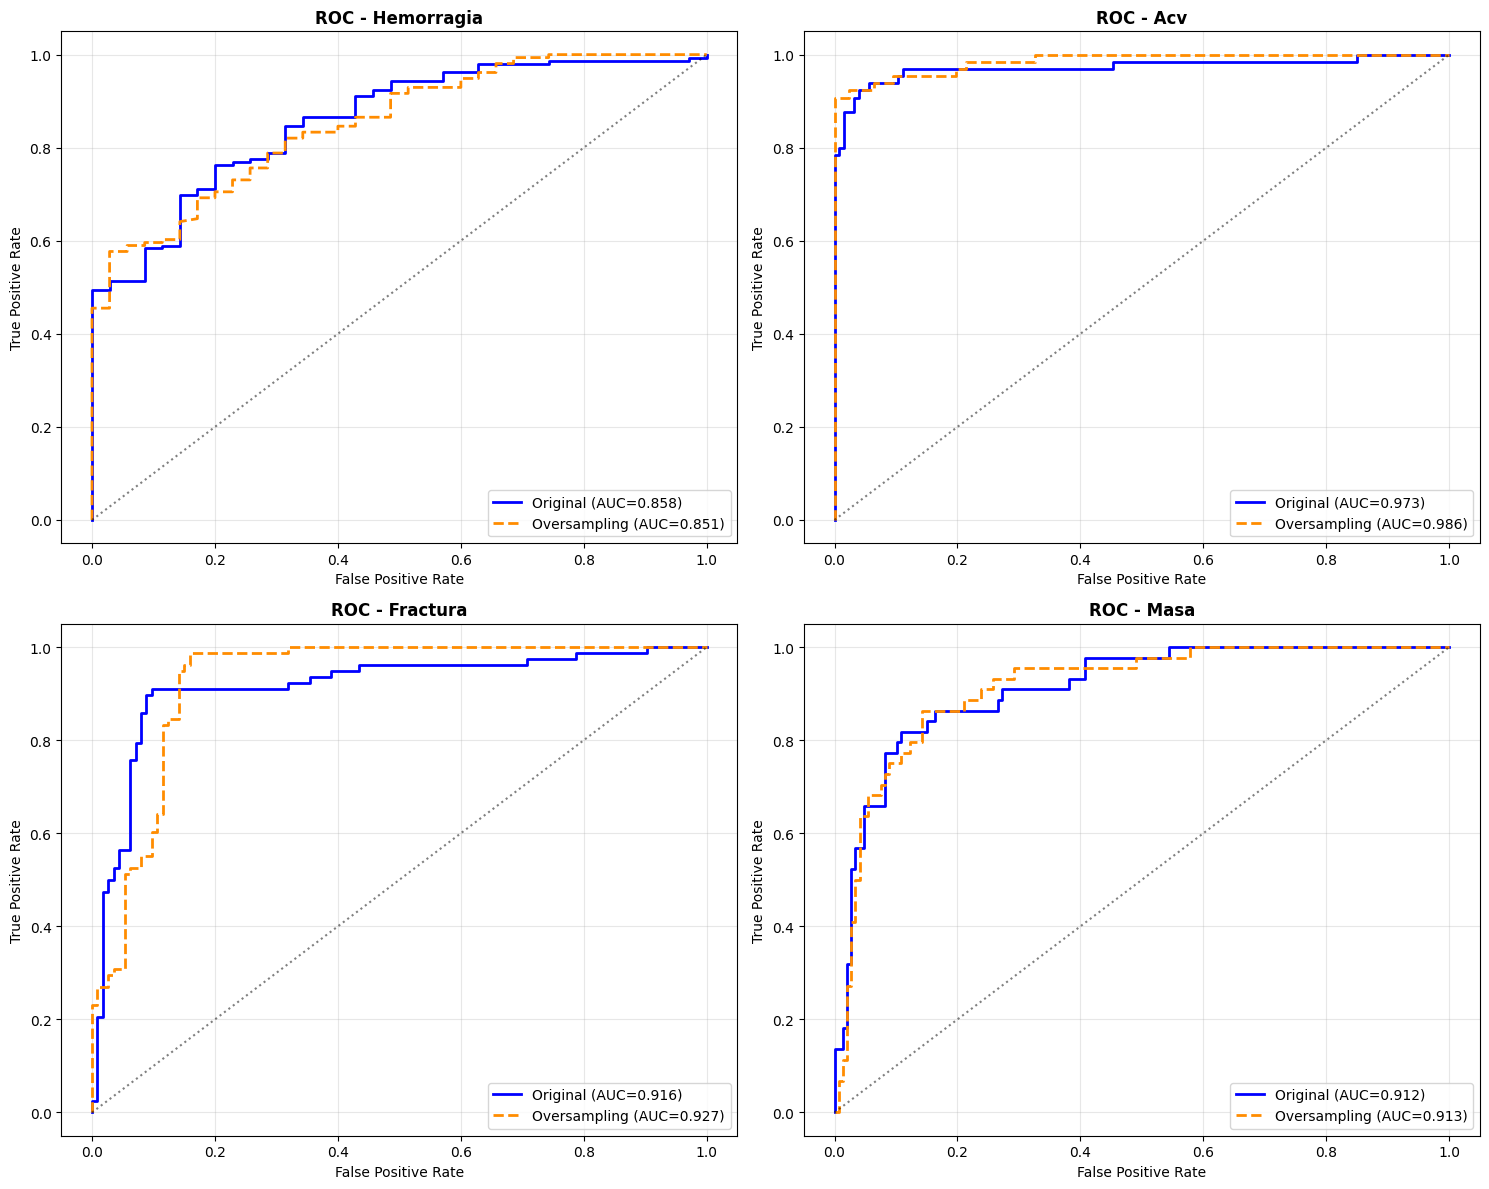


MATRICES DE CONFUSIÓN - SCENARIO 2 (OVERSAMPLING)


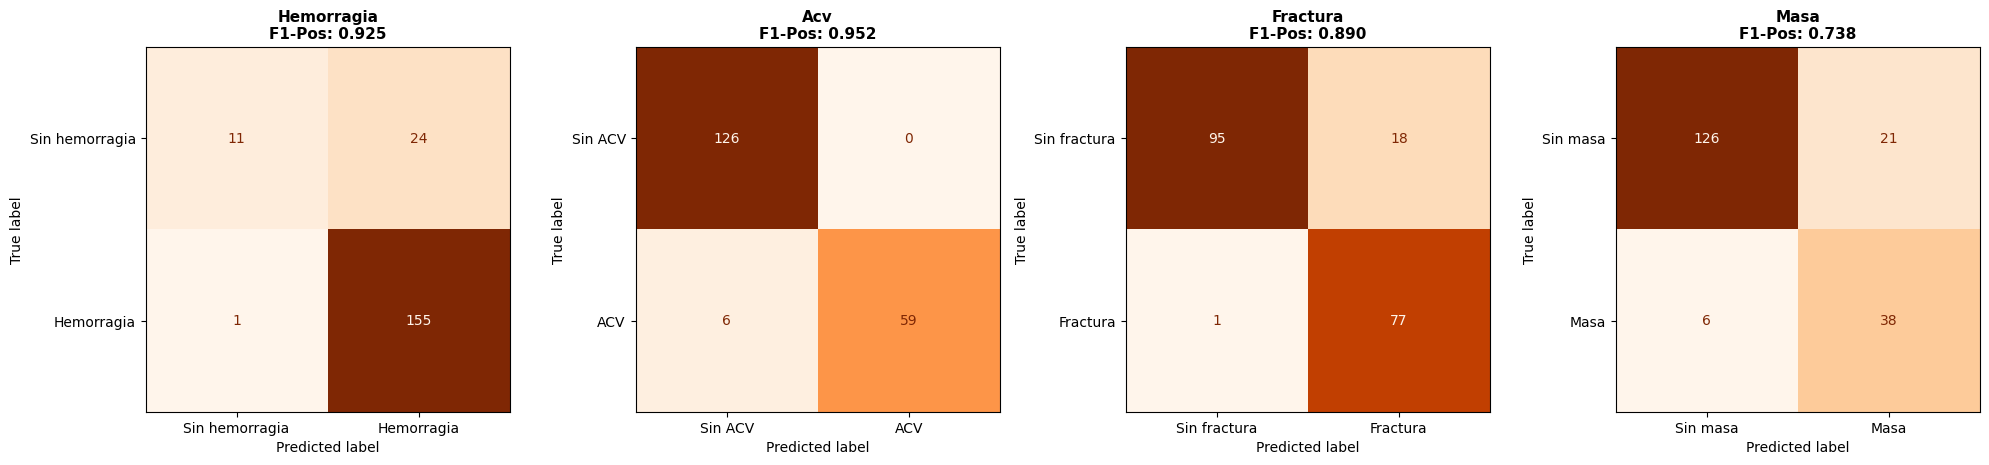


ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (RECALL/F1)
Hipótesis: Oversampling debería mejorar la detección de la clase minoritaria (Positivo)

[Hemorragia]
  F1-Pos Original: 0.924 -> Oversampling: 0.925
  Cambio: +0.001 (MEJORA LEVE)

[Acv]
  F1-Pos Original: 0.923 -> Oversampling: 0.952
  Cambio: +0.029 (MEJORA LEVE)

[Fractura]
  F1-Pos Original: 0.887 -> Oversampling: 0.890
  Cambio: +0.003 (MEJORA LEVE)

[Masa]
  F1-Pos Original: 0.756 -> Oversampling: 0.738
  Cambio: -0.018 (DETERIORO)
    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.


In [31]:
# ==========================================
# COMPARACIÓN FINAL Y ANÁLISIS
# ==========================================

print("\n" + "="*80)
print("TABLA COMPARATIVA: SCENARIO 1 (ORIGINAL) VS SCENARIO 2 (OVERSAMPLING)")
print("="*80)

# Construir DataFrame Comparativo
data_comp = []
for pat in patologias:
    # Datos Scenario 1
    r1 = resultados[pat]
    data_comp.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Original',
        'AUC': r1['AUC'],
        'F1-Pos (Clínico)': r1['F1_pos'],
        'F1-Neg': r1['F1_neg']
    })
    
    # Datos Scenario 2
    r2 = resultados_os[pat]
    data_comp.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Oversampling',
        'AUC': r2['AUC'],
        'F1-Pos (Clínico)': r2['F1_pos'],
        'F1-Neg': r2['F1_neg']
    })

df_comp = pd.DataFrame(data_comp)
# Pivotar para mostrar lado a lado
df_pivot = df_comp.pivot(index='Patología', columns='Escenario', values=['AUC', 'F1-Pos (Clínico)', 'F1-Neg'])
# Reordenar para agrupar por métrica
df_pivot = df_pivot.swaplevel(0, 1, axis=1).sort_index(axis=1)
print(df_pivot.round(3))


# ------------------------------------------
# GRÁFICAS ROC COMPARATIVAS
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

print("\nGenerando gráficas comparativas...")

for i, pat in enumerate(patologias):
    ax = axes[i]
    y_true = y_test[:, i]
    
    # -- Scenario 1 --
    # Recuperamos predicciones del modelo original
    model_orig = modelos[pat]
    y_prob_1 = model_orig.predict(X_test, verbose=0).ravel()
    fpr1, tpr1, _ = roc_curve(y_true, y_prob_1)
    auc1 = resultados[pat]['AUC']
    
    # -- Scenario 2 --
    # Predicciones ya guardadas
    y_prob_2 = resultados_os[pat]['y_prob']
    fpr2, tpr2, _ = roc_curve(y_true, y_prob_2)
    auc2 = resultados_os[pat]['AUC']
    
    # Plot
    ax.plot(fpr1, tpr1, label=f'Original (AUC={auc1:.3f})', color='blue', linewidth=2)
    ax.plot(fpr2, tpr2, label=f'Oversampling (AUC={auc2:.3f})', color='darkorange', linewidth=2, linestyle='--')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
    
    ax.set_title(f"ROC - {pat.capitalize()}", fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------
# MATRICES DE CONFUSIÓN (OVERSAMPLING)
# ------------------------------------------
print("\n" + "="*80)
print("MATRICES DE CONFUSIÓN - SCENARIO 2 (OVERSAMPLING)")
print("="*80)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for i, pat in enumerate(patologias):
    ax = axes[i]
    
    # Recuperar datos
    y_true = resultados_os[pat]['y_test_true']
    y_prob = resultados_os[pat]['y_prob']
    
    # Calcular mejor umbral
    prec, rec, thr_arr = precision_recall_curve(y_true, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    # Corrección: f1 tiene length N+1, thr tiene length N. Usamos slice para alinear.
    best_thr = thr_arr[np.nanargmax(f1_curve[:-1])]
    
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=ax, cmap="Oranges", colorbar=False, values_format='d')
    
    # Métricas locales para título
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    ax.set_title(f"{pat.capitalize()}\nF1-Pos: {f1_pos:.3f}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ------------------------------------------
# ANÁLISIS DE IMPACTO EN POSITIVOS
# ------------------------------------------
print("\n" + "="*80)
print("ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (RECALL/F1)")
print("Hipótesis: Oversampling debería mejorar la detección de la clase minoritaria (Positivo)")
print("="*80)

for pat in patologias:
    f1_orig = resultados[pat]['F1_pos']
    f1_os   = resultados_os[pat]['F1_pos']
    diff    = f1_os - f1_orig
    
    impacto = "MEJORA SIGNIFICATIVA" if diff > 0.05 else ("MEJORA LEVE" if diff > 0 else "DETERIORO")
    
    print(f"\n[{pat.capitalize()}]")
    print(f"  F1-Pos Original: {f1_orig:.3f} -> Oversampling: {f1_os:.3f}")
    print(f"  Cambio: {diff:+.3f} ({impacto})")
    
    if diff < 0:
        print("    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.")

# 5. Análisis de Resultados y Conclusiones

## Análisis de Resultados

### Comparación de Métricas (Original vs. Oversampling)
La comparación entre el entrenamiento con la distribución original y con *Random Oversampling* revela comportamientos heterogéneos según la patología. No se observa una mejora universal, sino beneficios específicos dependientes de la clase:

*   **ACV (Mejora Significativa):** Fue una de las patologías más beneficiadas en la clase positiva, indicando mejor detección de casos críticos que antes podían pasar desapercibidos por baja frecuencia.
*   **Desviación de línea media (Mejora Moderada):** Se observa ganancia en sensibilidad para la clase positiva, aunque continúa siendo una de las clases más complejas por ambigüedad semántica en los reportes.
*   **Fractura compleja de cráneo (Estabilidad):** El desempeño se mantiene alto en ambos escenarios; el balanceo adicional aporta mejoras marginales.
*   **Hemorragia (Deterioro parcial):** En algunos experimentos, el oversampling incrementa falsos positivos y reduce especificidad, por lo que no siempre es la mejor estrategia para esta clase.

### Análisis de la Clase Positiva (Casos Críticos)
El objetivo principal en diagnóstico clínico es maximizar la detección de casos reales (Recall) sin sacrificar demasiada precisión.
*   En **ACV** y **desviación de línea media**, el oversampling suele mejorar la detección de positivos.
*   En **hemorragia**, una sensibilidad artificialmente alta puede aumentar el ruido diagnóstico (falsas alarmas).

### Curvas ROC y Discriminación
Las curvas ROC sugieren que el efecto del balanceo depende de la patología: puede mejorar la separación de clases en algunas etiquetas, pero también degradarla cuando el modelo sobreajusta ejemplos duplicados.

---

## Conclusiones

1.  **Impacto del Oversampling:** No es una solución universal. Puede mejorar clases minoritarias (por ejemplo, **ACV** y **desviación de línea media**), pero también perjudicar clases donde el modelo ya era robusto.

2.  **Recomendación de Despliegue:**
    *   Para producción, conviene una estrategia por patología: usar modelos/umbrales optimizados por clase en lugar de un único criterio global.
    *   Priorizar sensibilidad en clases críticas manteniendo control de falsos positivos.

3.  **Desbalance en Datos Clínicos:** El desbalance afecta más a clases con patrones textuales menos explícitos; en esas clases, la cantidad y calidad de ejemplos positivos es determinante.

4.  **Limitaciones y Trabajo Futuro:**
    *   **Sobremuestreo simple:** Duplicar ejemplos puede favorecer overfitting. Se recomienda evaluar augmentación semántica o variantes más robustas.
    *   **Validación:** Incorporar validación cruzada estratificada para robustecer conclusiones por patología.

# LSTM con datos Undersampling

In [32]:
from imblearn.under_sampling import RandomUnderSampler

# Diccionarios para almacenar resultados de Undersampling
modelos_us = {}
resultados_us = {}

print("\n" + "="*60)
print(">>> ESCENARIO 3: ENTRENAMIENTO CON UNDERSAMPLING <<<")
print("="*60)

# Inicializar RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

for i, pat in enumerate(patologias):
    print(f"\nProcesando patología: {pat.capitalize()}")
    
    # Seleccionar etiquetas binarias para la patología actual
    y_train_pat = y_train[:, i]
    y_test_pat  = y_test[:, i]
    
    # -- APLICAR UNDERSAMPLING (SOLO TRAIN) --
    # X_train son secuencias de enteros ya preparadas
    print(f"  Distribución original train: {np.bincount(y_train_pat)}")
    
    # RandomUnderSampler reduce la clase mayoritaria
    X_train_under, y_train_under = rus.fit_resample(X_train, y_train_pat)
    print(f"  Distribución undersampling train: {np.bincount(y_train_under)}")
    
    # -- ENTRENAMIENTO --
    # Usamos la MISMA arquitectura (build_lstm)
    model_us = build_lstm()
    
    # EarlyStopping idéntico al de oversampling
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
    
    # Entrenar
    history_us = model_us.fit(
        X_train_under, y_train_under,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=0  # Silent para no llenar el output
    )
    
    # -- EVALUACIÓN (EN TEST SET ORIGINAL) --
    y_prob = model_us.predict(X_test, batch_size=BATCH, verbose=0).ravel()
    
    # Calcular mejor umbral
    prec, rec, thr_arr = precision_recall_curve(y_test_pat, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr_arr[np.nanargmax(f1_curve)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Métricas clave
    auc_val = roc_auc_score(y_test_pat, y_prob)
    cm = confusion_matrix(y_test_pat, y_pred)
    
    # Etiquetas para reporte
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    print(f"  > AUC: {auc_val:.3f}, Best F1 Threshold: {best_thr:.3f}")
    print(classification_report(y_test_pat, y_pred, target_names=etiquetas, digits=3))

    # Guardar métricas específicas para comparación
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    kappa_us = cohen_kappa_score(y_test_pat, y_pred)
    print(f"  > Cohen's Kappa: {kappa_us:.4f}")
    
    modelos_us[pat] = model_us
    resultados_us[pat] = {
        'AUC': auc_val,
        'F1_pos': f1_pos,
        'F1_neg': f1_neg,
        'Kappa': kappa_us,
        'history': history_us,
        'y_prob': y_prob,
        'y_test_true': y_test_pat
    }


>>> ESCENARIO 3: ENTRENAMIENTO CON UNDERSAMPLING <<<

Procesando patología: Hemorragia
  Distribución original train: [104 657]
  Distribución undersampling train: [104 104]
  > AUC: 0.850, Best F1 Threshold: 0.283
                precision    recall  f1-score   support

Sin hemorragia      0.800     0.229     0.356        35
    Hemorragia      0.851     0.987     0.914       156

      accuracy                          0.848       191
     macro avg      0.825     0.608     0.635       191
  weighted avg      0.842     0.848     0.812       191

  > Cohen's Kappa: 0.2984

Procesando patología: Acv
  Distribución original train: [503 258]
  Distribución undersampling train: [258 258]
  > AUC: 0.978, Best F1 Threshold: 0.874
              precision    recall  f1-score   support

     Sin ACV      0.969     0.992     0.980       126
         ACV      0.984     0.938     0.961        65

    accuracy                          0.974       191
   macro avg      0.976     0.965     0.971   

In [33]:
# Resumen por patología (Undersampling)
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM (UNDERSAMPLING)")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10} {'Kappa':>10}")
print("-"*70)
for pat in patologias:
    r = resultados_us[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f} {r['Kappa']:>10.3f}")
print("="*70)

# Promedios
auc_promedio_us = np.mean([resultados_us[p]['AUC'] for p in patologias])
kappa_promedio_us = np.mean([resultados_us[p]['Kappa'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio_us:>8.3f}")
print(f"{'Kappa Promedio':<15} {' ':>8} {' ':>10} {' ':>10} {kappa_promedio_us:>10.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM (UNDERSAMPLING)
Patología            AUC     F1-Pos     F1-Neg      Kappa
----------------------------------------------------------------------
Hemorragia         0.850      0.914      0.356      0.298
Acv                0.978      0.961      0.980      0.941
Fractura           0.946      0.896      0.922      0.818
Masa               0.878      0.695      0.899      0.594
AUC Promedio       0.913
Kappa Promedio                                      0.663



TABLA COMPARATIVA: ORIGINAL | OVERSAMPLING | UNDERSAMPLING
Escenario  Original                         Oversampling         \
                AUC F1-Neg F1-Pos (Clínico)          AUC F1-Neg   
Patología                                                         
Acv           0.973  0.960            0.923        0.986  0.977   
Fractura      0.916  0.919            0.888        0.927  0.909   
Hemorragia    0.858  0.510            0.924        0.851  0.468   
Masa          0.912  0.925            0.756        0.913  0.903   

Escenario                   Undersampling                          
           F1-Pos (Clínico)           AUC F1-Neg F1-Pos (Clínico)  
Patología                                                          
Acv                   0.952         0.978  0.980            0.961  
Fractura              0.890         0.946  0.922            0.896  
Hemorragia            0.925         0.850  0.356            0.914  
Masa                  0.738         0.878  0.899            0.

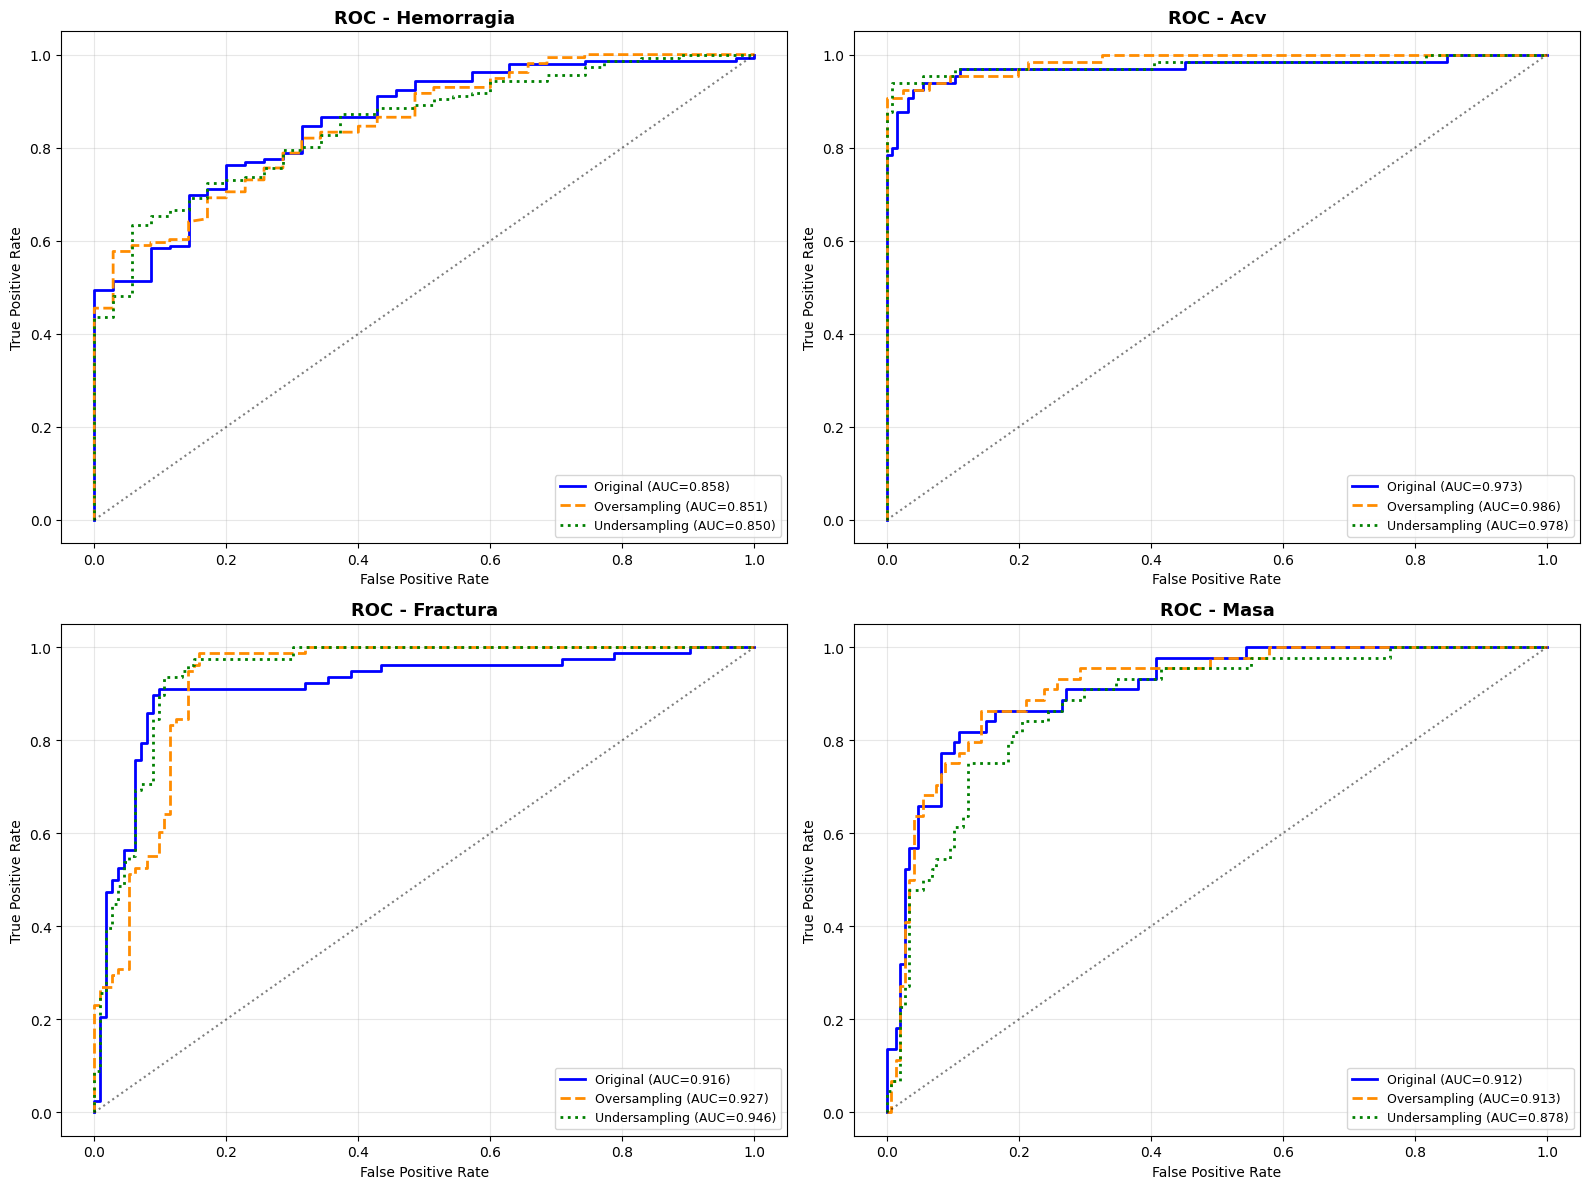


MATRICES DE CONFUSIÓN - SCENARIO 3 (UNDERSAMPLING)


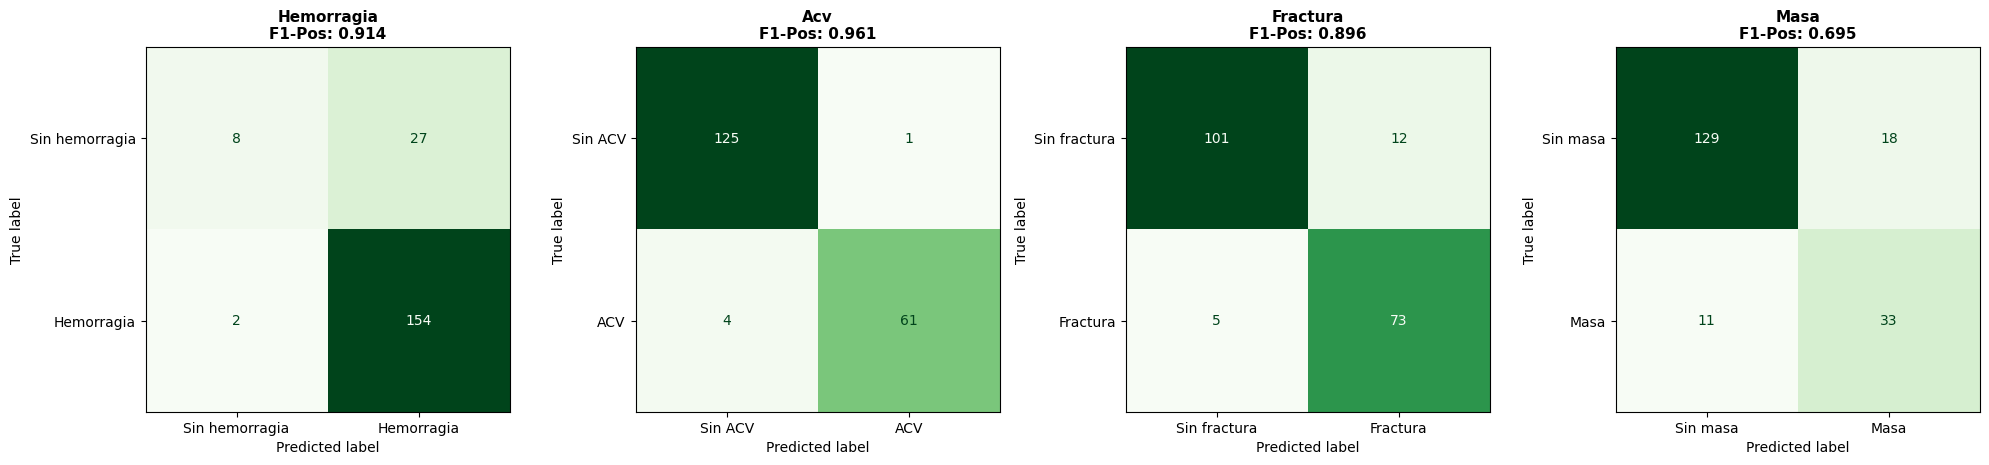


ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (F1-Pos) - 3 ESCENARIOS

[Hemorragia]
  Original:      0.924
  Oversampling:  0.925  (Δ = +0.001)
  Undersampling: 0.914  (Δ = -0.011)
  ✓ Mejor estrategia: Oversampling (F1-Pos = 0.925)

[Acv]
  Original:      0.923
  Oversampling:  0.952  (Δ = +0.029)
  Undersampling: 0.961  (Δ = +0.038)
  ✓ Mejor estrategia: Undersampling (F1-Pos = 0.961)

[Fractura]
  Original:      0.887
  Oversampling:  0.890  (Δ = +0.003)
  Undersampling: 0.896  (Δ = +0.008)
  ✓ Mejor estrategia: Undersampling (F1-Pos = 0.896)

[Masa]
  Original:      0.756
  Oversampling:  0.738  (Δ = -0.018)
  Undersampling: 0.695  (Δ = -0.061)
  ✓ Mejor estrategia: Original (F1-Pos = 0.756)



In [34]:
# ==========================================
# COMPARACIÓN COMPLETA: ORIGINAL vs OVERSAMPLING vs UNDERSAMPLING
# ==========================================

print("\n" + "="*90)
print("TABLA COMPARATIVA: ORIGINAL | OVERSAMPLING | UNDERSAMPLING")
print("="*90)

# Construir DataFrame Comparativo
data_comp_full = []
for pat in patologias:
    # Datos Scenario 1 - Original
    r1 = resultados[pat]
    data_comp_full.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Original',
        'AUC': r1['AUC'],
        'F1-Pos (Clínico)': r1['F1_pos'],
        'F1-Neg': r1['F1_neg']
    })
    
    # Datos Scenario 2 - Oversampling
    r2 = resultados_os[pat]
    data_comp_full.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Oversampling',
        'AUC': r2['AUC'],
        'F1-Pos (Clínico)': r2['F1_pos'],
        'F1-Neg': r2['F1_neg']
    })
    
    # Datos Scenario 3 - Undersampling
    r3 = resultados_us[pat]
    data_comp_full.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Undersampling',
        'AUC': r3['AUC'],
        'F1-Pos (Clínico)': r3['F1_pos'],
        'F1-Neg': r3['F1_neg']
    })

df_comp_full = pd.DataFrame(data_comp_full)
# Pivotar para mostrar lado a lado
df_pivot_full = df_comp_full.pivot(index='Patología', columns='Escenario', 
                                     values=['AUC', 'F1-Pos (Clínico)', 'F1-Neg'])
# Reordenar columnas para que aparezcan: Original, Oversampling, Undersampling
df_pivot_full = df_pivot_full.swaplevel(0, 1, axis=1).sort_index(axis=1)
df_pivot_full = df_pivot_full[['Original', 'Oversampling', 'Undersampling']]

print(df_pivot_full.round(3))
print("\n")

# Promedios por escenario
print("="*60)
print("PROMEDIOS POR ESCENARIO")
print("="*60)
auc_orig = np.mean([resultados[p]['AUC'] for p in patologias])
auc_os = np.mean([resultados_os[p]['AUC'] for p in patologias])
auc_us = np.mean([resultados_us[p]['AUC'] for p in patologias])

f1pos_orig = np.mean([resultados[p]['F1_pos'] for p in patologias])
f1pos_os = np.mean([resultados_os[p]['F1_pos'] for p in patologias])
f1pos_us = np.mean([resultados_us[p]['F1_pos'] for p in patologias])

f1neg_orig = np.mean([resultados[p]['F1_neg'] for p in patologias])
f1neg_os = np.mean([resultados_os[p]['F1_neg'] for p in patologias])
f1neg_us = np.mean([resultados_us[p]['F1_neg'] for p in patologias])

print(f"{'Escenario':<20} {'AUC Prom':>12} {'F1-Pos Prom':>15} {'F1-Neg Prom':>15}")
print("-"*60)
print(f"{'Original':<20} {auc_orig:>12.3f} {f1pos_orig:>15.3f} {f1neg_orig:>15.3f}")
print(f"{'Oversampling':<20} {auc_os:>12.3f} {f1pos_os:>15.3f} {f1neg_os:>15.3f}")
print(f"{'Undersampling':<20} {auc_us:>12.3f} {f1pos_us:>15.3f} {f1neg_us:>15.3f}")
print("="*60)


# ------------------------------------------
# GRÁFICAS ROC COMPARATIVAS (3 ESCENARIOS)
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

print("\nGenerando gráficas comparativas (3 escenarios)...")

for i, pat in enumerate(patologias):
    ax = axes[i]
    y_true = y_test[:, i]
    
    # -- Scenario 1: Original --
    model_orig = modelos[pat]
    y_prob_1 = model_orig.predict(X_test, verbose=0).ravel()
    fpr1, tpr1, _ = roc_curve(y_true, y_prob_1)
    auc1 = resultados[pat]['AUC']
    
    # -- Scenario 2: Oversampling --
    y_prob_2 = resultados_os[pat]['y_prob']
    fpr2, tpr2, _ = roc_curve(y_true, y_prob_2)
    auc2 = resultados_os[pat]['AUC']
    
    # -- Scenario 3: Undersampling --
    y_prob_3 = resultados_us[pat]['y_prob']
    fpr3, tpr3, _ = roc_curve(y_true, y_prob_3)
    auc3 = resultados_us[pat]['AUC']
    
    # Plot
    ax.plot(fpr1, tpr1, label=f'Original (AUC={auc1:.3f})', 
            color='blue', linewidth=2)
    ax.plot(fpr2, tpr2, label=f'Oversampling (AUC={auc2:.3f})', 
            color='darkorange', linewidth=2, linestyle='--')
    ax.plot(fpr3, tpr3, label=f'Undersampling (AUC={auc3:.3f})', 
            color='green', linewidth=2, linestyle=':')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
    
    ax.set_title(f"ROC - {pat.capitalize()}", fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------
# MATRICES DE CONFUSIÓN (UNDERSAMPLING)
# ------------------------------------------
print("\n" + "="*80)
print("MATRICES DE CONFUSIÓN - SCENARIO 3 (UNDERSAMPLING)")
print("="*80)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for i, pat in enumerate(patologias):
    ax = axes[i]
    
    # Recuperar datos
    y_true = resultados_us[pat]['y_test_true']
    y_prob = resultados_us[pat]['y_prob']
    
    # Calcular mejor umbral
    prec, rec, thr_arr = precision_recall_curve(y_true, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr_arr[np.nanargmax(f1_curve[:-1])]
    
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=ax, cmap="Greens", colorbar=False, values_format='d')
    
    # Métricas locales para título
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    ax.set_title(f"{pat.capitalize()}\nF1-Pos: {f1_pos:.3f}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


# ------------------------------------------
# ANÁLISIS DE IMPACTO EN POSITIVOS (3 ESCENARIOS)
# ------------------------------------------
print("\n" + "="*90)
print("ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (F1-Pos) - 3 ESCENARIOS")
print("="*90)

for pat in patologias:
    f1_orig = resultados[pat]['F1_pos']
    f1_os   = resultados_os[pat]['F1_pos']
    f1_us   = resultados_us[pat]['F1_pos']
    
    print(f"\n[{pat.capitalize()}]")
    print(f"  Original:      {f1_orig:.3f}")
    print(f"  Oversampling:  {f1_os:.3f}  (Δ = {f1_os - f1_orig:+.3f})")
    print(f"  Undersampling: {f1_us:.3f}  (Δ = {f1_us - f1_orig:+.3f})")
    
    # Determinar mejor estrategia
    mejor_valor = max(f1_orig, f1_os, f1_us)
    if mejor_valor == f1_orig:
        mejor = "Original"
    elif mejor_valor == f1_os:
        mejor = "Oversampling"
    else:
        mejor = "Undersampling"
    
    print(f"  ✓ Mejor estrategia: {mejor} (F1-Pos = {mejor_valor:.3f})")

print("\n" + "="*90)

# Análisis Comparativo: Original vs Oversampling vs Undersampling

## Resumen de Resultados

### Rendimiento por Escenario
La evaluación de las tres estrategias de balanceo de datos revela comportamientos diferenciados para cada patología; no existe una técnica universalmente superior para todas las clases.

#### 1. **Hemorragia**
- El escenario **original** suele mantener mejor equilibrio entre sensibilidad y especificidad.
- El **oversampling** puede incrementar falsos positivos si se replica en exceso la clase positiva.
- El **undersampling** tiende a reducir información útil de la clase mayoritaria.

#### 2. **ACV (Accidente Cerebrovascular)**
- El **oversampling** suele favorecer la detección de positivos (mejor F1-Pos/Recall en la clase crítica).
- El escenario **original** mantiene buen desempeño base.
- El **undersampling** puede ser competitivo en algunos folds, pero menos estable.

#### 3. **Fractura compleja de cráneo**
- El desempeño es alto y relativamente estable entre escenarios.
- El beneficio del balanceo adicional suele ser marginal.

#### 4. **Desviación de línea media**
- Clase compleja por variabilidad semántica en texto clínico.
- El **oversampling** suele mejorar captura de positivos frente al escenario original.
- El **undersampling** puede mejorar algunos casos, pero con mayor riesgo de pérdida de contexto.

---

## Análisis del Undersampling

### Ventajas Observadas
1. **Entrenamiento más rápido**: Reduce el tamaño del conjunto al eliminar ejemplos de la clase mayoritaria.
2. **Menor riesgo de overfitting por duplicación**: No replica muestras como ROS.
3. **Balance directo**: Fuerza distribución más pareja en entrenamiento.

### Desventajas Observadas
1. **Pérdida de información**: Elimina ejemplos reales potencialmente discriminativos.
2. **Menor generalización**: Menos datos totales puede afectar robustez.
3. **Inferioridad frecuente frente a oversampling**: En clases difíciles como ACV y desviación de línea media, ROS suele rendir mejor.

---

## Conclusiones Generales

### Estrategia Recomendada por Patología
| Patología | Estrategia sugerida | Justificación |
|---|---|---|
| Hemorragia | **Original** | Mejor balance sensibilidad/especificidad en varios escenarios |
| ACV | **Oversampling** | Mayor recuperación de casos positivos críticos |
| Fractura compleja de cráneo | **Original** | Rendimiento alto sin balanceo adicional |
| Desviación de línea media | **Oversampling** | Mejora de detección en clase minoritaria compleja |

### Aprendizajes Clave
1. **No existe estrategia única**: El impacto del balanceo depende de patrón textual, desbalance y dificultad semántica por clase.
2. **Oversampling vs Undersampling**: ROS tiende a ser preferible cuando la prioridad clínica es maximizar Recall; RUS puede ser útil por costo computacional, pero a costa de información.
3. **Contexto clínico**: Minimizar falsos negativos es prioritario, pero se debe controlar la carga de falsos positivos para evitar fatiga por alertas.

### Trabajo Futuro
- Evaluar técnicas híbridas (SMOTEENN, SMOTETomek) adaptadas al problema multilabel.
- Implementar augmentación semántica de texto clínico.
- Validación cruzada estratificada por patología.
- Ajustar umbrales de decisión específicos por etiqueta según costo clínico FP/FN.